The planet temperature for 10⁻⁶Mj/yr is: 2765.9658350411346
369234910.6773511
I_ff 12978690133266.014
F_ff 4.284883627811268e-06
I_ff_2 49885957696893.27
F_ff_2 6.98954234291013e-06
I_ff 153617918724.0372
F_ff 2.9447559977440725e-09


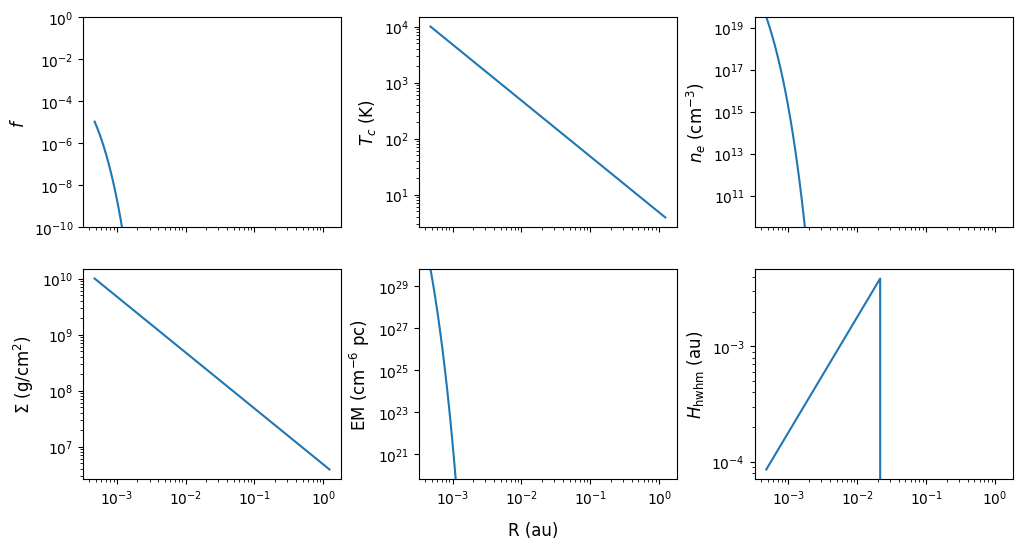

In [1]:
# Using Nautilus nested sampling to obtain the best fit parameters for the Zhu model given by our real data

import numpy as np
import matplotlib.pyplot as plt
from dusty_CPD import *
from free_free_CPD import *
from free_free_parametric_model import *
from nautilus import Prior
from units_astro import *
from nautilus import Sampler
import corner
from numpy import exp, log, log10, sqrt


In [2]:
# now for any parameter
def error_param(data, data_max, N=1000):
    array=np.zeros(N)
    bin=-15
    delta=30/len(array)
    for i in range(len(array)):
        array[i]=len(data[(data>bin) & (data<bin+delta)])
        bin+=delta

    # where we have the maximun
    bin_max=int((data_max+15)/delta)
    # now i want to know where is the 68% of the data
    sum=0
    i=0
    normalization=float(np.sum(array[bin_max:]))
    while sum<0.68*normalization:
        sum+=array[i+bin_max]
        i+=1

    # to the other side
    sum=0
    j=0
    normalization=float(np.sum(array[:bin_max]))
    while sum<0.68*normalization:
        sum+=array[bin_max-j]
        j+=1

    return (bin_max-j)*delta-15-data_max, (i+bin_max)*delta-15-data_max

def upper_limit(data, under_bound, N=1000):
    array=np.zeros(N)
    bin=float(under_bound)
    delta=(15-under_bound)/len(array)
    print(delta)
    for i in range(len(array)):
        array[i]=len(data[(data>bin) & (data<bin+delta)])
        bin+=delta
        
    # now i want to know where is the 99% of the data
    sum=0
    i=N-1
    normalization=float(np.sum(array))
    while sum<0.005*normalization:
        sum+=array[i]
        i-=1

    return (i)*delta+under_bound

In [3]:
# First our data with the error bars
nus = [97.5E9, 145005402197.7, 343.5E9, 671E9] # [nu1, nu2] are the x-axis values , 671E9
Fnus = [12e-06, 21.4e-06, 0.000121, 0.000143] # [Fnu1, Fnu2] are the y-axis values in Jy , 0.000122
sFnus = [4.7e-06, 4.1e-06, 0.000013, 0.000115] # [sigma_Fnu1, sigma_Fnu2] are the y-axis errors in Jy , 0.000090

# To mJy
nu = np.array(nus)
Fnus = np.array(Fnus)*1E3
sFnus = np.array(sFnus)*1E3


prior = Prior()
prior.add_parameter('log_T0', dist=(-15, 15))
prior.add_parameter('log_Sigma0', dist=(-30, 0))

R0 = Rin
print(R0/au)

0.0004778945025452157


In [4]:
# For log_alpha=-2
def likelihood(param_dict):
    T0 = 10**param_dict['log_T0']
    Sigma0 = 10**param_dict['log_Sigma0']
    
    ymodels = np.zeros(len(Fnus))
    Xis = np.zeros(len(Fnus))
    for i in range(len(Fnus)):
        ymodels[i] = F_ff_parametric(nu[i], R0, Sigma0, T0)
        Xis[i] = -0.5*((Fnus[i]-ymodels[i])/sFnus[i])**2
        
    return np.sum(Xis)

In [5]:
dict= {'log_T0': 5, 'log_Sigma0': -20}
likelihood(dict)

np.float64(-60.970734308152785)

In [6]:
# Corro el nested sampling de nautilus
sampler = Sampler(prior, likelihood, n_live=1000, pool=16)
sampler.run(verbose=True)

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 19     | 1        | 4        | 23184    | N/A    | 10066 | -11.39   


np.True_

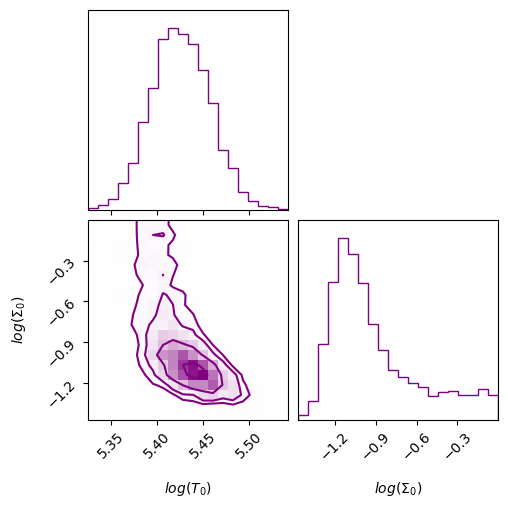

In [7]:
# Hacemos el corner plot

points, log_w, log_l = sampler.posterior()
corner.corner(
    points, weights=np.exp(log_w), bins=20, labels=[r'$log(T_0)$', r'$log(\Sigma_0)$'], color='purple',
    plot_datapoints=False, range=np.repeat(0.999, len(prior.keys)), fontsize=12)

# Save the log Z and the corner plot
np.save('logZ1.npy', log_l)
plt .savefig('corner_plot_ff_parametric.png')
plt.show()

In [8]:
# To see equal weights
points_equalw, log_w_equalw, log_l_equalw = sampler.posterior(equal_weight=True)

In [9]:
print('log(Z) =', log_l)
print('Evidence =', np.exp(log_l))
print('Best fit parameters =', np.mean(points, axis=0))
print('Errors =', np.std(points, axis=0))
print('The log likelihood is', likelihood({'log_T0': np.mean(points, axis=0)[0], 'log_Sigma0': np.mean(points, axis=0)[1]}))
# The best fit parameters are with the maximum likelihood
print('The maximum likelihood is', np.max(log_l))
print('The maximum likelihood parameters are')

# now making our errors
gamma_maxl, zeta_maxl = points[np.argmax(log_l)]
gamma_min, gamma_max = error_param(points_equalw[:,0], gamma_maxl)
zeta_min, zeta_max = error_param(points_equalw[:,1], zeta_maxl)

zeta_upper = upper_limit(points_equalw[:,1], -8)

print('gamma =', gamma_maxl, '+', gamma_max, '-', gamma_min)
print('zeta =', zeta_maxl, '+', zeta_max, '-', zeta_min)
print('zeta_upper =', zeta_upper)

log(Z) = [-60.97073431 -60.97073431 -60.97073431 ...  -1.09023216  -1.08842198
  -1.09511573]
Evidence = [3.31700810e-27 3.31700810e-27 3.31700810e-27 ... 3.36138447e-01
 3.36747469e-01 3.34500893e-01]
Best fit parameters = [ 5.05811747 -2.65929806]
Errors = [3.13357491 4.79637531]
The log likelihood is -55.78515501313252
The maximum likelihood is -1.0841342401809686
The maximum likelihood parameters are
0.023
gamma = 5.443701892955804 + 0.01629810704419654 - -0.07370189295580332
zeta = -1.1204453076187662 + 0.4004453076187655 - -0.13955469238123364
zeta_upper = -0.06500000000000039


In [10]:
# now making our spectral index best fit for the fluxes
T0 = 10**points[np.argmax(log_l)][0]
Sigma0 = 10**points[np.argmax(log_l)][1]

fluxes = np.zeros(len(nu))
for i in range(len(nu)):
    fluxes[i]=F_ff_parametric(nu[i], R0, Sigma0, T0)
    print('Flux at', round(nu[i]/1E9, 1), 'GHz =', fluxes[i])
    if i>0:
        print('Spectral index is ', (log(fluxes[i])-log(fluxes[i-1]))/(log(nu[i])-log(nu[i-1])))



Flux at 97.5 GHz = 0.011302979669872095
Flux at 145.0 GHz = 0.024332816830035298
Spectral index is  1.9317802400762323
Flux at 343.5 GHz = 0.1125840832961841
Spectral index is  1.7762590467156132
Flux at 671.0 GHz = 0.2697867571399504
Spectral index is  1.3051896197854416


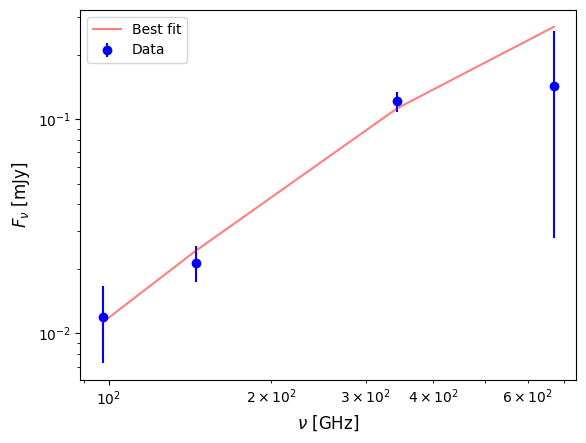

In [11]:
plt.errorbar(np.array(nus)/10**9, Fnus, yerr=sFnus, fmt='o', label='Data', color='blue')
plt.plot(np.array(nus)/10**9, fluxes, label='Best fit', alpha=0.5, color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\nu$ [GHz]', fontsize=12)
plt.ylabel(r'$F_{\nu}$ [mJy]', fontsize=12)
plt.legend(loc='upper left')
plt.savefig('best_fit_ff_zhu_fixed_alpha.png')
plt.show()

In [12]:
# array of frequencies
nu_arr=np.logspace(log10(nus[0]), log10(nus[-1]), 100)

# array of fluxes
F_arr=np.zeros(len(nu_arr))
F_arr_ff=np.zeros(len(nu_arr))
F_arr_zhu=np.zeros(len(nu_arr))

for i in range(len(nu_arr)):
    F_arr_ff[i]=F_ff_parametric(nu_arr[i], R0, Sigma0, T0)


/home/oriana/.local/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


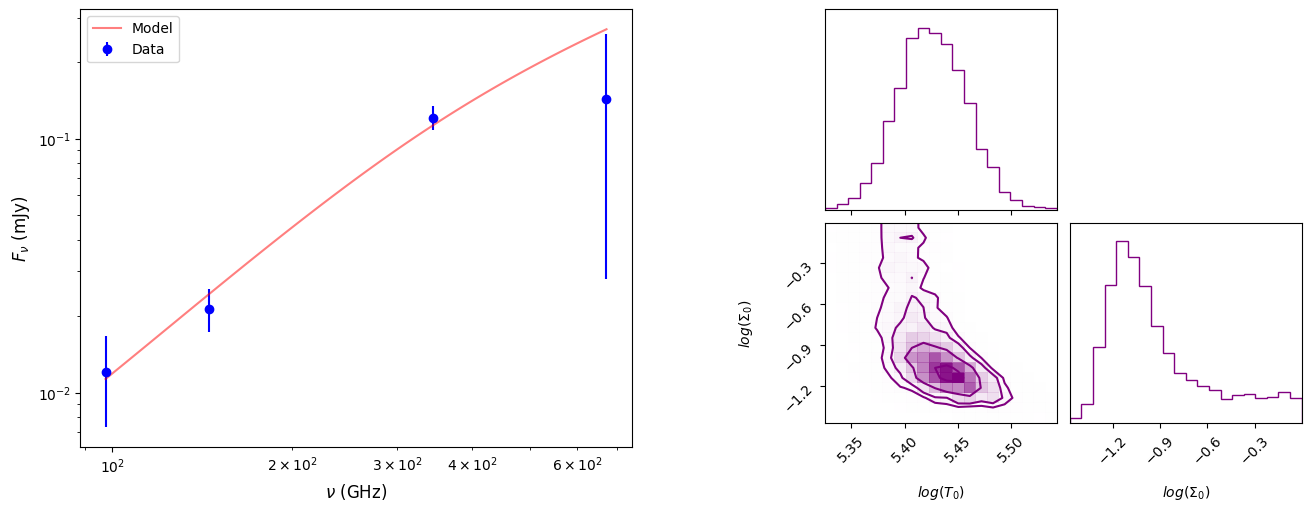

In [13]:
# vs the real data and the corner in the same plot
fig = plt.figure(layout='constrained', figsize=(13, 5))
subfigs = fig.subfigures(1, 2, width_ratios=[1.1, 1], wspace=0.15)

ax1 = subfigs[0].subplots(1, 1, sharey=True)
ax1.errorbar(np.array(nus)/10**9, Fnus, yerr=sFnus, fmt='o', label='Data', color='blue')
#ax1.plot(nu_arr/10**9, F_arr_ff, label='Free-free', linestyle=':', color='black')
#ax1.plot(nu_arr/10**9, F_arr_zhu, label='Dust',linestyle='--', color='green')
ax1.plot(nu_arr/10**9, F_arr_ff, label='Model', alpha=0.5, color='red')
ax1.loglog()
ax1.set_xlabel(r'$\nu$ (GHz)', fontsize=12)
ax1.set_ylabel(r'$F_{\nu}$ (mJy)', fontsize=12)
ax1.legend()


ax2 = subfigs[1]

corner.corner(
    points, weights=np.exp(log_w), bins=20, labels=[r'$log(T_0)$', r'$log(\Sigma_0)$'], color='purple',
    plot_datapoints=False, range=np.repeat(0.999, len(prior.keys)), fontsize=12, fig=ax2)


plt.savefig('fig_ff_parametric.png')
plt.show()



Sigma0 = 0.07578001595575223
The maximun ionization fraction is 1.0000002502497114


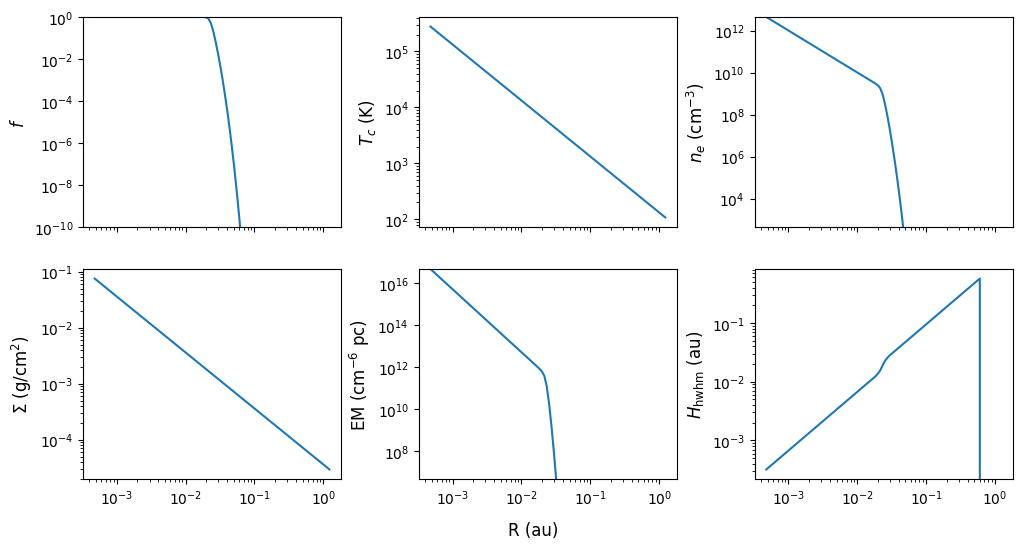

In [14]:
# The profile 
print('Sigma0 =', Sigma0)
R_arr, f_arr, T_c_arr, ne_arr, sigma_arr, EM_arr, z_arr_mid_f=profiles_ff_parametric(R0, Sigma0, T0)

#label x-axis instead of this sentence. use figsize, with width 17cm, and fontsize 12pt
fig, ax = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
fig.subplots_adjust(hspace=0.2, wspace=0.3)
fig.supxlabel('R (au)', fontsize=12)

ax[0,0].plot(R_arr/au, f_arr)
ax[0,0].set_ylabel(r'$f$', fontsize=12)
ax[0,0].set_xscale('log')
ax[0,0].set_yscale('log')
ax[0,0].set_ylim(1e-10,1)

ax[0,1].plot(R_arr/au, T_c_arr)
ax[0,1].set_ylabel(r'$T_{c}$ (K)', fontsize=12)
ax[0,1].set_xscale('log')
ax[0,1].set_yscale('log')

ax[0,2].plot(R_arr/au, ne_arr)
ax[0,2].set_ylabel(r'$n_{e}$ (cm$^{-3}$)', fontsize=12)
ax[0,2].set_xscale('log')
ax[0,2].set_yscale('log')
ax[0,2].set_ylim(max(ne_arr)*1e-10,max(ne_arr))

ax[1,0].plot(R_arr/au, sigma_arr)
ax[1,0].set_ylabel(r'$\Sigma$ (g/cm$^2$)', fontsize=12)
ax[1,0].set_xscale('log')
ax[1,0].set_yscale('log')

ax[1,1].plot(R_arr/au, EM_arr/pc)
ax[1,1].set_ylabel(r'EM (cm$^{-6}$ pc)', fontsize=12)
ax[1,1].set_xscale('log')
ax[1,1].set_yscale('log')
ax[1,1].set_ylim(max(EM_arr/pc)*1e-10,max(EM_arr/pc))

ax[1,2].plot(R_arr/au, z_arr_mid_f/au)
ax[1,2].set_ylabel(r'$H_{\rm hwhm}$ (au)', fontsize=12)
ax[1,2].set_xscale('log')
ax[1,2].set_yscale('log')


plt.savefig('profile_ff_parametric.png')
print('The maximun ionization fraction is', max(f_arr))

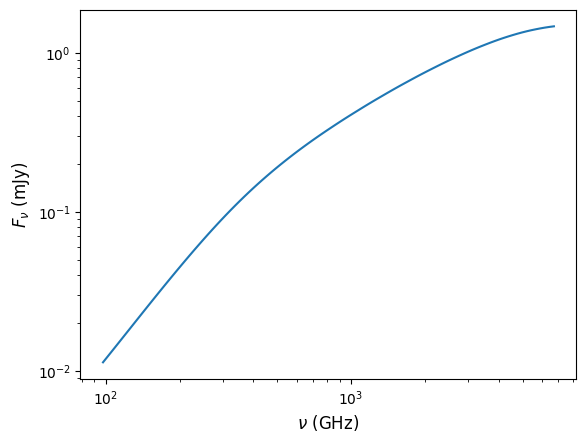

In [15]:
# and the spectral index
nu_arr=np.logspace(log10(nus[0]), log10(10*nus[-1]), 100)
F_arr=np.zeros(len(nu_arr))
for i in range(len(nu_arr)):
    F_arr[i]=F_ff_parametric(nu_arr[i], R0, Sigma0, T0)

plt.plot(nu_arr/10**9, F_arr)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\nu$ (GHz)', fontsize=12)
plt.ylabel(r'$F_{\nu}$ (mJy)', fontsize=12)
plt.show()